# Slater determinant → MPS, in JAX

A JAX port of `fishman_white_tutorial.ipynb`: same sections, same printed checks, same numbers.
What changes is the machinery.

| NumPy | here |
|---|---|
| `np.float64` by default | `jax_enable_x64`, set **before** the first array exists |
| in-place `U[p] = ...` | `U = U.at[p].set(...)` — arrays are immutable, so you must *rebind* |
| Python loop per rotation, per δ | `lax.scan` / `lax.fori_loop` inside one `jit`, `vmap` over δ |
| no derivatives | `jax.grad` through the compression (last section) |

Two things stay on the host deliberately: the block size `B` in `find_mode`, and the number of
singular values kept after an SVD. Both decide array *shapes*, which XLA needs at trace time.
The fixed-$B$ compression has neither problem, and is the part that gets jitted, vmapped and
differentiated.

In [1]:
from functools import partial

import jax
jax.config.update("jax_enable_x64", True)   # before anything touches jnp: eigh at float32
                                            # cannot resolve eps = 1e-12
import jax.numpy as jnp
from jax import jit, vmap, lax
import numpy as np                          # host-side bookkeeping, printing, matplotlib
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True, linewidth=110)
print(f"jax {jax.__version__} | {jax.devices()} | default float {jnp.zeros(1).dtype}")

jax 0.11.1 | [CpuDevice(id=0)] | default float float64


In [2]:
def ssh_hamiltonian(n, delta, t=1.0):
    """Dimerised chain: t1 = -t(1+delta/2), t2 = -t(1-delta/2); bulk gap 2|delta|t.

    No Python loop: one where() for the alternating off-diagonal.  n is a *shape*, so it
    has to stay a host int.
    """
    i = jnp.arange(n - 1)
    off = -t * jnp.where(i % 2 == 0, 1 + delta/2, 1 - delta/2)
    return jnp.diag(off, 1) + jnp.diag(off, -1)

def ssh_orbitals(n, Nf, delta=0.4):
    """Occupied orbitals U (n x Nf) of a dimerised hopping chain."""
    _, Ufull = jnp.linalg.eigh(ssh_hamiltonian(n, delta))
    return Ufull[:, :Nf]                      # lowest Nf levels

n, Nf = 10, 4
U = ssh_orbitals(n, Nf)
print(f"n = {n} sites, Nf = {Nf} fermions,  U has shape {U.shape}")
print(f"columns orthonormal: {np.allclose(U.T @ U, jnp.eye(Nf))}")

n = 10 sites, Nf = 4 fermions,  U has shape (10, 4)
columns orthonormal: True


In [3]:
@jit
def Lambda(U):
    """Correlation matrix, Eq. (5):  Lam_ij = <a_i^dag a_j> = sum_k U_ik U_jk."""
    return U @ U.conj().T

Lam = Lambda(U)
nb = jnp.linalg.eigvalsh(Lam)
print("eigenvalues n_b of Lambda:", nb)
print(f"\nmax |n_b - nearest of {{0,1}}| = {jnp.minimum(jnp.abs(nb), jnp.abs(1-nb)).max():.2e}")
print(f"projector?  max |Lam^2 - Lam| = {jnp.abs(Lam @ Lam - Lam).max():.2e}")

eigenvalues n_b of Lambda: [-0. -0.  0.  0.  0.  0.  1.  1.  1.  1.]

max |n_b - nearest of {0,1}| = 7.77e-16
projector?  max |Lam^2 - Lam| = 3.33e-16


In [4]:
def find_mode(Lam, k, eps=1e-8, Bmax=12):
    """Smallest block at site k containing an eigenvalue equal to 0 or 1 with a tolerance eps.

    The loop bound depends on the numbers, so this one stays a host loop and each
    `float(...) < eps` is a blocking transfer off the device.  That is the price of the
    adaptive version; the fixed-B sweep below pays none of it.
    """
    n = Lam.shape[0]
    for B in range(2, min(Bmax, n - k) + 1):
        nb, W = jnp.linalg.eigh(Lam[k:k+B, k:k+B])       # static slice: B is a host int
        if float(jnp.minimum(nb[0], 1.0 - nb[-1])) < eps:
            break
    if nb[0] <= 1.0 - nb[-1]:
        return B, W[:, 0], 0                    # lowest eigenvalue is nearest 0 -> empty
    return B, W[:, -1], 1                       # highest is nearest 1 -> filled

for eps in [1e-2, 1e-6, 1e-12]:
    B, v, occ = find_mode(Lambda(U), 0, eps=eps)
    print(f"  eps = {eps:.0e}  ->  B = {B}, mode is {'filled' if occ else 'empty '},"
          f"  |v| on block = {np.abs(v).round(3)}")

  eps = 1e-02  ->  B = 3, mode is empty ,  |v| on block = [0.683 0.7   0.206]
  eps = 1e-06  ->  B = 4, mode is empty ,  |v| on block = [0.641 0.701 0.302 0.085]
  eps = 1e-12  ->  B = 5, mode is empty ,  |v| on block = [0.604 0.689 0.368 0.159 0.021]


In [5]:
def V(theta):
    """Single-particle Givens rotation, Eq. (7)."""
    c, s = jnp.cos(theta), jnp.sin(theta)
    return jnp.array([[c, -s],
                      [s,  c]])

def rotate_rows(U, p, theta):
    """Apply V(theta)^T to rows p, p+1 of U.  Returns a NEW array: no in-place in JAX.

    Written with .at[] so it works for a host int p and for a traced p under jit.
    """
    c, s = jnp.cos(theta), jnp.sin(theta)
    rp, rq = U[p], U[p+1]
    return U.at[p].set(c*rp + s*rq).at[p+1].set(-s*rp + c*rq)

def zeroing_angles(v, k):
    """Angles that rotate v onto its first entry, and the bond each one acts on.

    B-1 rotations, known once B is, so the sweep is a lax.scan.  Returns (ps, thetas)
    in derivation order; the first acts on the last pair of the block, (k+B-2, k+B-1).
    """
    def step(v, j):
        theta = jnp.arctan2(v[j], v[j-1])
        c, s = jnp.cos(theta), jnp.sin(theta)
        v = v.at[j-1].set(c*v[j-1] + s*v[j]).at[j].set(0.0)
        return v, theta
    js = jnp.arange(v.shape[0] - 1, 0, -1)
    _, thetas = lax.scan(step, v, js)
    return np.asarray(k + js - 1), thetas       # ps go to the host: they index Python lists

B, v, occ = find_mode(Lambda(U), 0, eps=1e-12)
ps, thetas = zeroing_angles(v, 0)
print(f"B = {B}  ->  {len(ps)} = B-1 rotations")
print("  (site p, theta) in derivation order:")
for p, t in zip(ps, thetas): print(f"     acts on sites ({p}, {p+1})   theta = {t:+.6f}")
print(f"\n  first gate acts on sites ({ps[0]}, {ps[0]+1})  == (k+B-2, k+B-1)")

B = 5  ->  4 = B-1 rotations
  (site p, theta) in derivation order:
     acts on sites (3, 4)   theta = +3.008325
     acts on sites (2, 3)   theta = +0.410310
     acts on sites (1, 2)   theta = +2.614293
     acts on sites (0, 1)   theta = +0.922338

  first gate acts on sites (3, 4)  == (k+B-2, k+B-1)


In [6]:
def fw_decompose(U, eps=1e-8, Bmax=12):
    """Full decomposition of the correlation matrix given by U.

    Returns
      occ   : (n,) occupations n_k of the product state
      gates : [(p, theta), ...] rotations, in the order they were DERIVED
      Bs    : block size used at each site (diagnostic)
    """
    U = jnp.asarray(U, dtype=jnp.float64)
    n = U.shape[0]
    occ, gates, Bs = np.zeros(n, int), [], []
    for k in range(n - 1):
        # Lambda(U) MUST be recomputed here.  It looks like a loop invariant, but U is
        # rebound below every step, so hoisting it out of the loop silently breaks the
        # algorithm: from step 2 on you diagonalise a stale correlation matrix, the
        # occupations come out wrong (typically all zero) and the "MPS" is the vacuum.
        # The JAX version of that bug is forgetting the `U =` on the next line.
        B, v, o = find_mode(Lambda(U), k, eps=eps, Bmax=Bmax)
        occ[k] = o
        Bs.append(B)
        for p, theta in zip(*zeroing_angles(v, k)):
            U = rotate_rows(U, p, theta)      # keep U (hence Lambda) in the rotated basis
            gates.append((int(p), theta))
    occ[n-1] = int(round(float(U[n-1] @ U[n-1])))   # whatever is left on the last site

    # Every step rotates inside the degenerate occupied/empty subspaces, so the particle
    # number cannot change.  If it did, every downstream number would be meaningless.
    if occ.sum() != U.shape[1]:
        raise RuntimeError(
            f"particle number lost: sum n_k = {occ.sum()} but Nf = {U.shape[1]}. "
            "Either eps is too loose / Bmax too small, or Lambda was not recomputed.")
    return occ, gates, Bs

occ, gates, Bs = fw_decompose(U, eps=1e-10)
print("occupations n_k :", occ)
print(f"sum n_k = {occ.sum()}  (must equal Nf = {Nf})   -> OK")
print("block sizes B   :", Bs)
print(f"number of gates : {len(gates)}  (= sum of B-1 over steps = {sum(b-1 for b in Bs)})")
print("\n(the last two entries may come out swapped against the NumPy notebook: that block is")
print(" exactly degenerate, so the branch is a roundoff coin flip -- the state is the same)")

occupations n_k : [0 0 0 1 0 1 1 0 0 1]
sum n_k = 4  (must equal Nf = 4)   -> OK
block sizes B   : [5, 5, 5, 4, 4, 3, 3, 2, 2]
number of gates : 24  (= sum of B-1 over steps = 24)

(the last two entries may come out swapped against the NumPy notebook: that block is
 exactly degenerate, so the branch is a roundoff coin flip -- the state is the same)


In [7]:
@jit
def V_hat(theta):
    """Many-body two-site gate, Eq. (9).  Returned as [out_p, out_q, in_p, in_q].

    Built with .at[] rather than a nested list, so it traces and V_hat can be jitted.
    """
    c, s = jnp.cos(theta), jnp.sin(theta)
    g = jnp.eye(4).at[1, 1].set(c).at[1, 2].set(s).at[2, 1].set(-s).at[2, 2].set(c)
    return g.reshape(2, 2, 2, 2)

def product_mps(occ):
    """The starting product state |n_1 n_2 ... n_n> as a bond-dimension-1 MPS."""
    return [jax.nn.one_hot(int(o), 2).reshape(1, 2, 1) for o in occ]

def mps_to_dense(mps):
    """Contract to a 2**n amplitude vector (site 0 is the most significant bit)."""
    psi = mps[0][0]
    for A in mps[1:]:
        psi = jnp.tensordot(psi, A, axes=([-1], [0]))
    return psi.reshape(-1)

th = 0.3
print("V_hat(0.3) =\n", V_hat(th).reshape(4, 4))
print("\nunitary:", np.allclose(V_hat(th).reshape(4,4) @ V_hat(th).reshape(4,4).T, jnp.eye(4)))
print("product state occupations recovered:",
      [int(jnp.argmax(A[0, :, 0])) for A in product_mps(occ)])

V_hat(0.3) =
 [[ 1.      0.      0.      0.    ]
 [ 0.      0.9553  0.2955  0.    ]
 [ 0.     -0.2955  0.9553  0.    ]
 [ 0.      0.      0.      1.    ]]

unitary: True
product state occupations recovered: [0, 0, 0, 1, 0, 1, 1, 0, 0, 1]


## 7. Applying the gates — and why the order is **reversed**

> *"We then apply, one by one, all of the nearest neighbor gates $\{\hat V_i\}$ … **in the
> opposite order in which they were obtained** with our diagonalization procedure."*

The reason: $\hat W(V)$ defined by $\hat W a^\dagger_\alpha \hat W^\dagger=\sum_i V_{i\alpha}a^\dagger_i$
is a homomorphism, $\hat W(V)\hat W(V')=\hat W(VV')$. The decomposition produced
$V=g_1g_2\cdots g_M$ in derivation order, so

$$|\Psi\rangle=\hat W(V)|n\rangle=\hat W(g_1)\cdots\hat W(g_M)|n\rangle$$

and $g_M$ — the **last** gate derived — is the one that touches the product state **first**.

Each gate is applied by contracting two neighbouring tensors, acting with $\hat V$, and splitting
with an SVD, discarding small singular values. The contraction and SVD are one jitted kernel;
the truncation is not, because `keep` fixes the shape of the next tensor.

The $2^n$ reference state is where JAX pays off in this section: the tutorial's `creation` loops
over nonzero amplitudes in Python (`np.nonzero` has a data-dependent shape). Precompute, for the
whole basis at once, where each bit flip lands and the Jordan–Wigner sign it carries — then
$a^\dagger_i$ is a gather and a whole orbital $\sum_i U_{ik}a^\dagger_i$ is one matvec.

In [8]:
@jit
def gate_and_svd(Al, Ar, theta):
    """Contract two tensors, act with V_hat(theta), SVD the result.  Shapes are static."""
    T = jnp.tensordot(Al, Ar, axes=1)                     # (Dl, 2, 2, Dr)
    T = jnp.einsum("xypq,apqb->axyb", V_hat(theta), T)
    Dl, _, _, Dr = T.shape
    return jnp.linalg.svd(T.reshape(Dl*2, 2*Dr), full_matrices=False)

def apply_gate(mps, p, theta, chi_max=None, cutoff=1e-12):
    """Act with V_hat(theta) on sites (p, p+1) and split again by SVD.  Returns a NEW list."""
    Dl, Dr = mps[p].shape[0], mps[p+1].shape[2]
    W, S, Vt = gate_and_svd(mps[p], mps[p+1], theta)
    keep = int(jnp.sum(S > cutoff * jnp.maximum(S[0], 1e-300)))   # host sync: keep is a shape
    if chi_max is not None:
        keep = min(keep, chi_max)                                  # cap the bond dimension
    keep = max(keep, 1)
    out = list(mps)
    out[p]   = W[:, :keep].reshape(Dl, 2, keep)
    out[p+1] = (S[:keep, None] * Vt[:keep]).reshape(keep, 2, Dr)
    return out

def build_mps(occ, gates, chi_max=None, cutoff=1e-12, reverse=True):
    """Grow the MPS from the product state.  reverse=False only to show it is wrong."""
    mps = product_mps(occ)
    for p, theta in (reversed(gates) if reverse else gates):
        mps = apply_gate(mps, p, theta, chi_max, cutoff)
    return mps

def bond_dimension(mps):
    return max(A.shape[0] for A in mps)

# Check MPS vs exact SD
def jw_tables(n):
    """Tables turning every a_i^dag and a_i into one gather over the 2**n basis.

    flipped[j,i] : basis state j with site i's bit flipped
    sign_c[j,i]  : JW sign of a_i^dag mapping flipped[j,i] -> j, zero where forbidden
    sign_a[j,i]  : the same for a_i
    """
    j = jnp.arange(2 ** n)
    weight = 1 << jnp.arange(n - 1, -1, -1)                 # site 0 is the top bit
    bits = (j[:, None] >> jnp.arange(n - 1, -1, -1)) & 1    # (2**n, n) occupations
    below = jnp.concatenate([jnp.zeros((2 ** n, 1), bits.dtype),
                             jnp.cumsum(bits, axis=1)[:, :-1]], axis=1)
    jw = 1.0 - 2.0 * (below % 2)                            # (-1)**sum(bits[:i])
    return dict(flipped=j[:, None] ^ weight,
                sign_c=jnp.where(bits == 1, jw, 0.0),
                sign_a=jnp.where(bits == 0, jw, 0.0))

def creation_all(psi, tab):
    """(2**n, n) array whose column i is a_i^dag |psi>, with the JW sign."""
    return tab["sign_c"] * psi[tab["flipped"]]

def exact_determinant(U, tab=None):
    """|Psi> = prod_k (sum_i U_ik a_i^dag) |Omega>  as a dense 2**n vector."""
    n, Nf = U.shape
    tab = jw_tables(n) if tab is None else tab
    psi = jnp.zeros(2 ** n).at[0].set(1.0)
    for k in range(Nf - 1, -1, -1):
        psi = creation_all(psi, tab) @ U[:, k]              # one matvec per orbital
    return psi / jnp.linalg.norm(psi)

tab = jw_tables(n)
psi_exact = exact_determinant(U, tab)
print(f"exact state: {2**n} amplitudes, norm {jnp.linalg.norm(psi_exact):.12f}")

mps = build_mps(occ, gates, cutoff=1e-14, reverse=True)
psi = mps_to_dense(mps); psi /= jnp.linalg.norm(psi)
print(f" |<MPS|Psi_exact>| = {abs(psi @ psi_exact):.12f}")

exact state: 1024 amplitudes, norm 1.000000000000
 |<MPS|Psi_exact>| = 1.000000000000


## 8. The bond dimension is $2^{B-1}$

> *"picking a block size $B$ for diagonalizing the correlation matrix would correspond to an
> MPS with a bond dimension of $\chi=2^{B-1}$."*

Each step contributes $B-1$ gates straddling a given bond, and each gate can at most double the
bond dimension. Forcing the block size (tiny `eps`, so $B$ always grows to `Bmax`) and
truncating only numerically-zero singular values reproduces this exactly — and shows the
fidelity climbing as $B$ grows.

Note the cutoff must be a small *finite* number: with `cutoff=0` the SVD also keeps singular
values that are zero to roundoff, and $\chi$ is then inflated by pure noise.

In [9]:
# Check that max bond dimension should be 2^(B-1)
rows = []
for Bmax in [2, 3, 4, 5, 6]:
    o, g, bs = fw_decompose(U, eps=1e-14, Bmax=Bmax)
    mps = build_mps(o, g, cutoff=1e-14)
    psi = mps_to_dense(mps); psi /= jnp.linalg.norm(psi)
    B_used = max(bs)
    rows.append((Bmax, B_used, bond_dimension(mps), 2**(B_used - 1), abs(psi @ psi_exact)))

print("  Bmax   B used   chi    2**(B_used-1)   |<MPS|Psi_exact>|")
for Bmax, Bu, chi, pred, fid in rows:
    print(f"   {Bmax:2d}      {Bu:2d}     {chi:4d}       {pred:6d}        {fid:.12f}")
print("\nchi == 2**(B_used-1) for every row:", all(chi == pred for _, _, chi, pred, _ in rows))

  Bmax   B used   chi    2**(B_used-1)   |<MPS|Psi_exact>|
    2       2        2            2        0.885796289068
    3       3        4            4        0.997626204682
    4       4        8            8        0.999976153435
    5       5       16           16        1.000000000000
    6       5       16           16        1.000000000000

chi == 2**(B_used-1) for every row: True


  chi_max =   1   chi =   1   infidelity = 9.468e-01
  chi_max =   2   chi =   2   infidelity = 1.790e-01
  chi_max =   4   chi =   4   infidelity = 1.321e-02
  chi_max =   8   chi =   8   infidelity = 1.296e-03
  chi_max =  16   chi =  16   infidelity = 0.000e+00
  chi_max =  32   chi =  16   infidelity = 0.000e+00


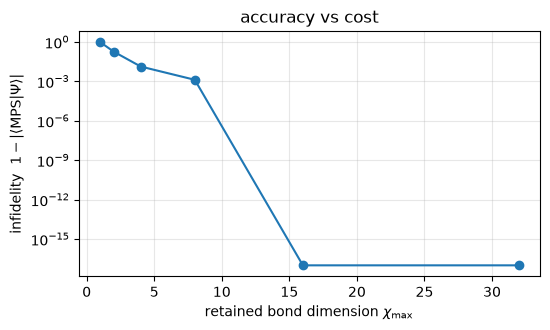

In [10]:
o, g, bs = fw_decompose(U, eps=1e-14, Bmax=6)
chis = [1, 2, 4, 8, 16, 32]
infid = []
for cm in chis:
    mps = build_mps(o, g, chi_max=cm, cutoff=1e-14)
    psi = mps_to_dense(mps); psi /= jnp.linalg.norm(psi)
    infid.append(max(1.0 - abs(float(psi @ psi_exact)), 0.0))
    print(f"  chi_max = {cm:3d}   chi = {bond_dimension(mps):3d}   infidelity = {infid[-1]:.3e}")

fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.semilogy(chis, np.maximum(infid, 1e-17), "o-")
ax.set_xlabel(r"retained bond dimension $\chi_{\max}$")
ax.set_ylabel(r"infidelity  $1-|\langle\mathrm{MPS}|\Psi\rangle|$")
ax.set_title("accuracy vs cost"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### An independent check: the correlation matrix comes back

Fidelity against a $2^n$ vector only works for small $n$. The physical check that scales is to
measure $\Lambda_{ij}=\langle a^\dagger_i a_j\rangle$ on the MPS and compare with $UU^{\mathsf T}$.
With the Jordan–Wigner tables it is one Gram matrix: apply every $a_i$ at once, then $A^{\mathsf T}A$.

In [11]:
def annihilation_all(psi, tab):
    """(2**n, n) array whose column i is a_i |psi>."""
    return tab["sign_a"] * psi[tab["flipped"]]

def correlation_from_state(psi, n, tab=None):
    """Lam_ij = <a_i^dag a_j> = (a_i|psi>).(a_j|psi>), as a single Gram matrix."""
    tab = jw_tables(n) if tab is None else tab
    A = annihilation_all(psi, tab)              # (2**n, n)
    return A.T @ A

mps = build_mps(occ, gates, cutoff=1e-14)
psi = mps_to_dense(mps); psi /= jnp.linalg.norm(psi)
print(f"max |Lambda_from_MPS - U U^T| = "
      f"{jnp.abs(correlation_from_state(psi, n, tab) - U @ U.T).max():.2e}")

max |Lambda_from_MPS - U U^T| = 4.28e-15


## 10. Reproducing Fig. 1(a) — why any of this works

Fig. 1(a) is the observation the whole method rests on. Diagonalise a block of $B=16$
consecutive sites in the middle of a gapless half-filled chain of $N=1000$ sites, and look at
the block eigenvalues $n_b$ together with the single-mode entropy

$$S_1(n_b)=-\big[n_b\log n_b+(1-n_b)\log(1-n_b)\big]$$

A block of $B$ sites could in principle carry volume-law entanglement, $S_B\le B\log 2$. What
actually happens is that **most $n_b$ are exponentially close to 0 or 1** and so contribute
essentially nothing to $S_1$; only the two eigenvalues nearest $\tfrac12$ matter. Those nearly
pure modes are exactly what the algorithm harvests — and, in the last section, exactly what
makes the naive gradient blow up.

The caption gives three numbers to check: $n_1$ and $1-n_{16}$ both $\approx1.74\times10^{-11}$,
$\tfrac12-n_8=n_9-\tfrac12\approx0.21$, and $S_1(n_8)=S_1(n_9)\approx0.60$ against a maximum of
$S_1(\tfrac12)=\log 2\approx0.69$.

In [12]:
@jit
def S1(nu):
    """Single-mode entanglement entropy; vanishes at n = 0 and n = 1."""
    nu = jnp.clip(nu, 1e-300, 1.0 - 1e-300)
    return -(nu*jnp.log(nu) + (1 - nu)*jnp.log(1 - nu))

N_f1, B_f1 = 1000, 16
Lam_f1 = Lambda(ssh_orbitals(N_f1, N_f1 // 2, delta=0.0))   # delta = 0: uniform, gapless

k_f1 = 491                                   # sites 492..507 (1-indexed), per Fig. 1(b)
nb_f1 = jnp.linalg.eigvalsh(Lam_f1[k_f1:k_f1+B_f1, k_f1:k_f1+B_f1])
S_f1 = S1(nb_f1)

print(f"block = sites {k_f1+1}..{k_f1+B_f1} of {N_f1}\n")
print("   b        n_b          S1(n_b)")
for i, (x, s) in enumerate(zip(nb_f1, S_f1), 1):
    print(f"  {i:2d}   {x:.6e}     {s:.4f}")

print("\ncaption checks")
for label, got, want in [("n_1",             nb_f1[0],        1.74e-11),
                         ("1 - n_16",        1 - nb_f1[-1],   1.74e-11),
                         ("1/2 - n_8",       0.5 - nb_f1[7],  0.21),
                         ("n_9 - 1/2",       nb_f1[8] - 0.5,  0.21),
                         ("S1(n_8)",         S_f1[7],         0.60),
                         ("S1(n_9)",         S_f1[8],         0.60),
                         ("S1(1/2) = log 2", S1(0.5),         0.69)]:
    ok = "ok" if abs(got - want) <= 0.01*max(abs(want), 1e-12) + 0.005 else "MISMATCH"
    print(f"  {label:16s} = {got:.4e}   paper {want:.2e}   {ok}")

block = sites 492..507 of 1000

   b        n_b          S1(n_b)
   1   1.742266e-11     0.0000
   2   3.024848e-09     0.0000
   3   2.056946e-07     0.0000
   4   9.199480e-06     0.0001
   5   2.378847e-04     0.0022
   6   4.479508e-03     0.0287
   7   4.851167e-02     0.1941
   8   2.883470e-01     0.6007
   9   7.116530e-01     0.6007
  10   9.514883e-01     0.1941
  11   9.955205e-01     0.0287
  12   9.997621e-01     0.0022
  13   9.999908e-01     0.0001
  14   9.999998e-01     0.0000
  15   1.000000e+00     0.0000
  16   1.000000e+00     0.0000

caption checks
  n_1              = 1.7423e-11   paper 1.74e-11   ok
  1 - n_16         = 1.7421e-11   paper 1.74e-11   ok
  1/2 - n_8        = 2.1165e-01   paper 2.10e-01   ok
  n_9 - 1/2        = 2.1165e-01   paper 2.10e-01   ok
  S1(n_8)          = 6.0066e-01   paper 6.00e-01   ok
  S1(n_9)          = 6.0066e-01   paper 6.00e-01   ok
  S1(1/2) = log 2  = 6.9315e-01   paper 6.90e-01   ok


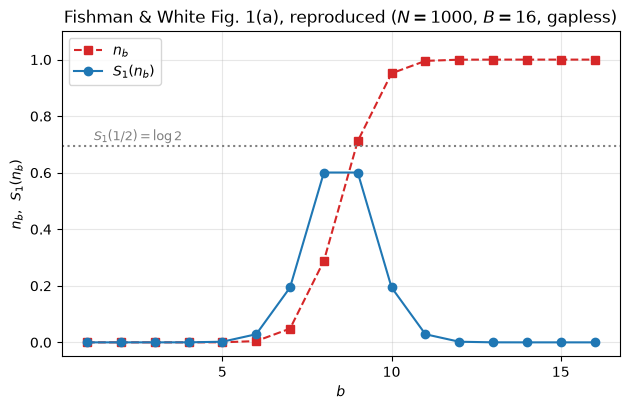

10 of 16 eigenvalues are within 1e-3 of 0 or 1, contributing 0.0047 to the entropy;
the two nearest 1/2 alone contribute 1.2013 of the total 1.6516.
A volume law would allow up to B log 2 = 11.09.


In [13]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
b_idx = np.arange(1, B_f1 + 1)
ax.plot(b_idx, nb_f1, "s--", color="tab:red",  label=r"$n_b$")
ax.plot(b_idx, S_f1,  "o-",  color="tab:blue", label=r"$S_1(n_b)$")
ax.axhline(np.log(2), ls=":", color="gray")
ax.text(1.2, np.log(2) + 0.02, r"$S_1(1/2)=\log 2$", color="gray", fontsize=9)
ax.set_xlabel(r"$b$"); ax.set_ylabel(r"$n_b$,  $S_1(n_b)$")
ax.set_title(r"Fishman & White Fig. 1(a), reproduced ($N=1000$, $B=16$, gapless)")
ax.set_xticks([5, 10, 15]); ax.set_ylim(-0.05, 1.1)
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

pure = np.asarray(jnp.minimum(nb_f1, 1 - nb_f1) < 1e-3)
print(f"{int(pure.sum())} of {B_f1} eigenvalues are within 1e-3 of 0 or 1, contributing"
      f" {S_f1[pure].sum():.4f} to the entropy;")
print(f"the two nearest 1/2 alone contribute {S_f1[7] + S_f1[8]:.4f} of the total {S_f1.sum():.4f}.")
print(f"A volume law would allow up to B log 2 = {B_f1*np.log(2):.2f}.")

## 11. The fixed-$B$ compression: the part JAX was waiting for

With $B$ held fixed nothing about the sweep depends on the data — $n-1$ site steps, each one
$B\times B$ `eigh` plus $B-1$ rotations — so the whole thing compiles, batches and
differentiates. Four things are done differently from the NumPy version:

1. The $B-1$ rotations of a step all live inside the same $B\times B$ block, so accumulate them
   there into one small orthogonal $Q$ (`lax.scan`) and update $\Lambda$ and $R$ with two
   matmuls instead of $4(B-1)$ scatters into an $n\times n$ array. Same arithmetic, XLA-shaped.
2. The site loop is a `lax.fori_loop`, compiled once per `(n, B)` instead of unrolled $n$ times.
   The tail, where the block must shrink below $B$, is a short unrolled loop over *static* sizes.
3. `energy_compressed` cannot select rows with `R[occ == 1]` — a boolean mask has no static
   shape. Use $n_k\in\{0,1\}$ as **weights**: same number, static shape, and differentiable.
4. Two `custom_jvp` rules, so that `jax.grad` works. They are needed because of Fig. 1(a): the
   block eigenvalues cluster exponentially close to 0 and 1, and an eigenvector derivative
   carries $1/(\lambda_i-\lambda_j)$, which is `nan` past about $B=10$. The mixing *inside* a
   degenerate cluster is gauge — every vector in it is equally near-pure and extracts the same
   determinant — so those terms are projected out. Neither rule changes a primal value.

In [14]:
DEGENERACY_TOL = 1e-9    # eigenvalues this close count as one cluster: mixing them is gauge
NOISE_TOL      = 1e-28   # x^2 + y^2 below this: both components are eigensolver noise

@jax.custom_jvp
def extreme_mode(blk):
    """The eigenvector of blk nearest 0 or 1, and its eigenvalue."""
    nb, W = jnp.linalg.eigh(blk)
    empty = nb[0] <= 1.0 - nb[-1]
    return jnp.where(empty, W[:, 0], W[:, -1]), jnp.where(empty, nb[0], nb[-1])

@extreme_mode.defjvp
def extreme_mode_jvp(primals, tangents):
    """Perturbation theory with the degenerate cluster projected out:
    dv = sum_j w_j <w_j|dA|v>/(lam - nb_j), skipping every j within DEGENERACY_TOL of lam.
    Those are the terms that overflow, and they rotate v among equally pure modes."""
    (blk,), (dblk,) = primals, tangents
    nb, W = jnp.linalg.eigh(blk)
    empty = nb[0] <= 1.0 - nb[-1]
    v   = jnp.where(empty, W[:, 0], W[:, -1])
    lam = jnp.where(empty, nb[0], nb[-1])
    dblk = 0.5 * (dblk + dblk.T)            # blk is symmetric; so is its tangent
    c, gap = W.T @ (dblk @ v), lam - nb
    live = jnp.abs(gap) > DEGENERACY_TOL    # excludes j = i (gap 0) and the whole cluster
    dv = W @ jnp.where(live, c / jnp.where(live, gap, 1.0), 0.0)
    return (v, lam), (dv, v @ (dblk @ v))

@jax.custom_jvp
def zeroing_angle(y, x):
    """arctan2, with the derivative frozen where both arguments are numerically zero."""
    return jnp.arctan2(y, x)

@zeroing_angle.defjvp
def zeroing_angle_jvp(primals, tangents):
    """(x dy - y dx)/(x^2+y^2) is 0/0 where the mode has no weight on this pair of sites
    at all -- it happens in the tail.  The angle is then arbitrary, so freeze it."""
    (y, x), (dy, dx) = primals, tangents
    r2 = x*x + y*y
    live = r2 > NOISE_TOL
    return jnp.arctan2(y, x), jnp.where(live, (x*dy - y*dx) / jnp.where(live, r2, 1.0), 0.0)

def givens_block(v, b):
    """The b-1 zeroing rotations of v, accumulated into one b x b orthogonal Q.

    Q = G_0 G_1 ... G_{b-2}, exactly the product the tutorial applies row by row, in the
    same derivation order, with G_p the embedded [[c, s], [-s, c]].
    """
    def step(carry, j):
        v, Q = carry
        theta = zeroing_angle(v[j], v[j-1])
        c, s = jnp.cos(theta), jnp.sin(theta)
        v = v.at[j-1].set(c*v[j-1] + s*v[j]).at[j].set(0.0)
        return (v, rotate_rows(Q, j-1, theta)), theta
    (v, Q), thetas = lax.scan(step, (v, jnp.eye(b)), jnp.arange(b - 1, 0, -1))
    return Q, thetas

def compress_step(Lam, R, occ, k, b):
    """One site step of the fixed-B sweep.  b must be static; k may be traced."""
    n = Lam.shape[0]
    v, lam = extreme_mode(lax.dynamic_slice(Lam, (k, k), (b, b)))
    Q, _ = givens_block(v, b)
    # Lambda -> V^T Lambda V and R -> V^T R, for the whole product V of this step
    Lam = lax.dynamic_update_slice(Lam, Q @ lax.dynamic_slice(Lam, (k, 0), (b, n)), (k, 0))
    Lam = lax.dynamic_update_slice(Lam, lax.dynamic_slice(Lam, (0, k), (n, b)) @ Q.T, (0, k))
    R   = lax.dynamic_update_slice(R,   Q @ lax.dynamic_slice(R,   (k, 0), (b, n)), (k, 0))
    return Lam, R, occ.at[k].set(jnp.where(lam > 0.5, 1, 0))

@partial(jit, static_argnames=("B",))
def compress_at_fixed_B(Lam0, B):
    """Fishman-White compression with the block size held FIXED at B.

    Instead of growing B until a mode is pure to some tolerance (as in `find_mode`), we
    take the most nearly pure mode the B x B block offers.
    Returns (occ, R) so that  Lambda_c = R^T diag(occ) R.
    """
    n = Lam0.shape[0]
    B = min(B, n)
    Lam, R, occ = Lam0, jnp.eye(n), jnp.zeros(n, jnp.int32)
    Lam, R, occ = lax.fori_loop(0, n - B + 1,
                                lambda k, c: compress_step(*c, k, B), (Lam, R, occ))
    for b in range(B - 1, 1, -1):            # the tail: the block shrinks, sizes are static
        Lam, R, occ = compress_step(Lam, R, occ, n - b, b)
    return occ.at[n - 1].set(jnp.round(Lam[n - 1, n - 1]).astype(occ.dtype)), R

@jit
def energy_compressed(h, occ, R):
    """Tr(h Lambda_c) = sum_k n_k (R_k . h . R_k), using h tridiagonal.

    occ enters as a weight, not a mask: R[occ == 1] has a shape XLA cannot know.
    """
    diag, off = jnp.diag(h), jnp.diag(h, 1)
    per_mode = (R**2) @ diag + 2.0 * (R[:, :-1] * R[:, 1:]) @ off
    return occ.astype(R.dtype) @ per_mode

In [15]:
nc, dl = 32, 0.4
h = ssh_hamiltonian(nc, dl)
eps_sp, Vsp = jnp.linalg.eigh(h)
Nf_c = nc // 2
E0 = eps_sp[:Nf_c].sum()
Lam0 = Vsp[:, :Nf_c] @ Vsp[:, :Nf_c].T

occ_f, R_f = compress_at_fixed_B(Lam0, nc)               # B = N: exact
Lam_c = R_f.T @ jnp.diag(occ_f.astype(float)) @ R_f
print(f"B = N : sum n_k = {occ_f.sum()} (Nf = {Nf_c}),"
      f"  max|Lam_c - Lam| = {jnp.abs(Lam_c - Lam0).max():.2e}")
print(f"        relative energy error = "
      f"{abs(energy_compressed(h, occ_f, R_f) - E0)/abs(E0):.2e}")

occ_s, R_s = compress_at_fixed_B(Lam0, 4)                # small B: approximate
Lam_s = R_s.T @ jnp.diag(occ_s.astype(float)) @ R_s
print(f"\nB = 4 : relative energy error = "
      f"{abs(energy_compressed(h, occ_s, R_s) - E0)/abs(E0):.2e}")
print(f"        still a projector? max|Lam_c^2 - Lam_c| = "
      f"{jnp.abs(Lam_s @ Lam_s - Lam_s).max():.2e}  -> still a Slater determinant")

B = N : sum n_k = 16 (Nf = 16),  max|Lam_c - Lam| = 1.28e-15
        relative energy error = 0.00e+00

B = 4 : relative energy error = 5.05e-05
        still a projector? max|Lam_c^2 - Lam_c| = 4.44e-16  -> still a Slater determinant


### The criterion: smallest $B$ with relative energy error $<10^{-6}$

One guard worth keeping: at too small a $B$ the compression can lose a particle
($\sum_k n_k \ne N_f$). Those $B$ are rejected outright rather than being scored on energy.

The scan is turned inside out compared with the NumPy version: $B$ is a shape, so it stays in
the host loop, and every $\delta$ is done at once under `vmap` — one batched XLA program per $B$.

In [16]:
def sd_data(n, delta):
    """Single-particle data of one half-filled chain: h, Lambda, E0, and the gap."""
    h = ssh_hamiltonian(n, delta)
    eps_sp, Vsp = jnp.linalg.eigh(h)
    Nf = n // 2                                    # half filling
    Occ = Vsp[:, :Nf]
    return h, Occ @ Occ.T, eps_sp[:Nf].sum(), eps_sp[Nf] - eps_sp[Nf-1]

@partial(jit, static_argnames=("B",))
def block_error(h, Lam0, E0, B):
    """Relative energy error of the fixed-B compression, and its particle number."""
    occ, R = compress_at_fixed_B(Lam0, B)
    return jnp.abs(energy_compressed(h, occ, R) - E0) / jnp.abs(E0), occ.sum()

def min_block_size(n, deltas, tol=1e-6, Bmax=40):
    """Smallest B with relative energy error < tol, for every delta at once.

    Returns (B, gap, rel) arrays; B = -1 if no B <= min(Bmax, n) qualifies.  The gap is
    the *calculated* one, eps[Nf] - eps[Nf-1], the x axis of Fig. 10.
    """
    deltas = jnp.asarray(deltas, dtype=float)
    h, Lam0, E0, gap = vmap(partial(sd_data, n))(deltas)
    B_out, rel_out = np.full(deltas.size, -1), np.full(deltas.size, np.nan)
    for B in range(2, min(Bmax, n) + 1):
        rel, num = vmap(partial(block_error, B=B))(h, Lam0, E0)
        rel, num = np.asarray(rel), np.asarray(num)
        take = (num == n // 2) & (rel < tol) & (B_out < 0)   # first B that qualifies wins
        B_out[take], rel_out[take] = B, rel[take]
        if (B_out > 0).all():
            break
    return B_out, np.asarray(gap), rel_out

In [17]:
N_fig10 = 128
deltas = [0.0, 0.025, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0, 1.2, 1.6, 2.0]
blocks, gaps, rels = min_block_size(N_fig10, deltas)
print("  delta   calculated gap   2|delta|t   B    rel. energy error")
for d, gap, Bv, rel in zip(deltas, gaps, blocks, rels):
    print(f"  {d:5.3f}   {gap:12.6f}   {2*d:9.3f}   {Bv:2d}   {rel:.2e}")

  delta   calculated gap   2|delta|t   B    rel. energy error
  0.000       0.048706       0.000    9   1.00e-07
  0.025       0.084639       0.050    8   6.01e-07
  0.050       0.126226       0.100    8   3.01e-07
  0.100       0.217252       0.200    7   7.83e-07
  0.150       0.312713       0.300    7   2.52e-07
  0.200       0.410011       0.400    7   9.07e-08
  0.300       0.606953       0.600    6   3.16e-07
  0.400       0.805260       0.800    6   8.17e-08
  0.600       1.203414       1.200    5   3.10e-07
  0.800       1.602395       1.600    5   4.20e-08
  1.000       2.001724       2.000    4   7.00e-07
  1.200       2.401233       2.400    4   1.20e-07
  1.600       3.200523       3.200    4   8.84e-10
  2.000       4.000000       4.000    2   0.00e+00


In [ ]:
# Fig.11 of the paper: for gapless fermions B scales like ln(N)
Ns = [8, 16, 32, 64, 128, 256, 512, 1024]
B_of_N, rels14 = [], []
print("     N     B    rel. energy error")
for N in Ns:
    Bv, _, rel = min_block_size(N, [0.0])
    B_of_N.append(int(Bv[0])); rels14.append(float(rel[0]))
    print(f"  {N:5d}   {B_of_N[-1]:3d}   {rels14[-1]:.2e}")

slope, intercept = np.polyfit(np.log(Ns), B_of_N, 1)
resid = np.max(np.abs(np.array(B_of_N) - (slope*np.log(Ns) + intercept)))
print(f"\nleast-squares fit:  B = {slope:.3f} ln(N) + {intercept:.3f}")
print(f"largest deviation from the fit: {resid:.2f}  (B is an integer, so <1 is as good as it gets)")

fig, axR = plt.subplots(figsize=(6.0, 4.0))
lnN = np.log(Ns)
axR.plot(lnN, B_of_N, "o", color="tab:red", label="measured")
axR.plot(lnN, slope*lnN + intercept, "--", color="gray",
         label=rf"fit $B={slope:.2f}\ln N{intercept:+.2f}$")
axR.set_xlabel(r"$\ln N$")
axR.set_ylabel(r"block size $B$ for rel. energy error $< 10^{-6}$")
axR.set_title(r"against $\ln N$: straight, so $B\sim\ln N$")
axR.set_yticks(range(min(B_of_N), max(B_of_N) + 1)); axR.grid(alpha=0.3); axR.legend()
plt.tight_layout(); plt.show()

expo = slope * np.log(2)
print("B grows by about one per doubling of N -- linear in ln N, not in N.")
print(f"Hence chi ~ 2**(B-1) ~ N**{expo:.2f}, polynomial in N even for a critical state:")
for N in [Ns[0], Ns[-1]]:
    Bv = slope*np.log(N) + intercept
    print(f"    N = {N:5d}  ->  B ~ {Bv:4.1f}  ->  chi ~ 2**(B-1) ~ {2**(Bv-1):,.0f}")

     N     B    rel. energy error
      8     5   1.87e-16
     16     6   8.74e-08
     32     7   9.92e-08
     64     8   1.01e-07


## 13. Gradients

The compression above differentiates — reverse and forward mode — and central differences are
the referee. The payoff is a question the paper does not ask: Figs. 10 and 11 size $B$ by the
error in the **energy**, but what does a *force* $\partial E/\partial\delta$ cost?

Two caveats, both real. The occupations are integers chosen by a comparison, so the gradient is
a **branch** derivative: exact where the branch is stable — the $\delta$ sweeps below agree with
finite differences to $10^{-10}$ — but along an arbitrary orbital direction the compressed energy
is only piecewise smooth, and no finite difference agrees better than a few times $10^{-6}$.
And the truncated-SVD split of section 7 does **not** differentiate: the discarded singular
values are degenerate, so the standard SVD derivative gives `nan`. For a fidelity gradient,
contract the gates onto the $2^n$ state instead.

In [ ]:
def exact_energy(delta, n):
    """E0 = sum of the occupied single-particle levels."""
    return jnp.linalg.eigvalsh(ssh_hamiltonian(n, delta))[:n//2].sum()

def compressed_energy(delta, n, B):
    """E = Tr(h Lambda_c) for the fixed-B compression of the half-filled chain."""
    h = ssh_hamiltonian(n, delta)
    eps_sp, Vsp = jnp.linalg.eigh(h)
    Occ = Vsp[:, :n//2]
    occ, R = compress_at_fixed_B(Occ @ Occ.T, B)
    return energy_compressed(h, occ, R)

def central_diff(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2*h)

N_ad = 32
print(f"N = {N_ad}, delta = 0:  AD against central differences\n")
print("  quantity              grad         jacfwd       central fd    max rel")
for label, fnc in [("exact E0(delta)", partial(exact_energy, n=N_ad))] + \
                  [(f"E_c, B = {B:2d}", partial(compressed_energy, n=N_ad, B=B))
                   for B in [3, 6, 10, 16, N_ad]]:
    g, fw = float(jax.grad(fnc)(0.0)), float(jax.jacfwd(fnc)(0.0))
    ref = float(central_diff(fnc, 0.0))
    print(f"  {label:20s} {g:+.7f}   {fw:+.7f}   {ref:+.7f}   "
          f"{max(abs(g-ref), abs(fw-ref))/abs(ref):.1e}")
print("\n(without the two custom_jvp rules these are nan for every B >= 12)")
print(f"grad composes with jit and vmap: "
      f"{np.asarray(jax.jit(vmap(partial(jax.grad(compressed_energy), n=N_ad, B=6)))(jnp.array([0.2, 0.4, 0.6]))).round(6)}")

N_force = 128
print(f"\nhow big must B be for a force?  N = {N_force}")
print("  delta   B for 1e-6 in E   B for 1e-6 in dE/d(delta)")
for d_f in [0.0, 0.4]:
    E0_f = float(exact_energy(d_f, N_force))
    F0_f = float(jax.grad(partial(exact_energy, n=N_force))(d_f))
    Bs_f = range(2, 13)
    errE = [abs(float(compressed_energy(d_f, N_force, B)) - E0_f)/abs(E0_f) for B in Bs_f]
    errF = [abs(float(jax.grad(partial(compressed_energy, n=N_force, B=B))(d_f)) - F0_f)/abs(F0_f)
            for B in Bs_f]
    B_E = next((b for b, e in zip(Bs_f, errE) if e < 1e-6), None)
    B_F = next((b for b, e in zip(Bs_f, errF) if e < 1e-6), None)
    print(f"  {d_f:5.2f}        {B_E:2d}                 {B_F:2d}")
    print(f"          E     " + "  ".join(f"{e:.1e}" for e in errE))
    print(f"          dE/dd " + "  ".join(f"{e:.1e}" for e in errF))
print("\nThe force error runs two to three orders of magnitude above the energy error at the")
print("same B, so the 1e-6 criterion costs one to two more block sites -- a factor of two to")
print("four in chi.  At delta = 0, B = 3 gets the energy to 2% and the force wrong by 10x.")

N = 32, delta = 0:  AD against central differences

  quantity              grad         jacfwd       central fd    max rel
  exact E0(delta)      -1.2758242   -1.2758242   -1.2758242   1.6e-10
  E_c, B =  3          -2.7159330   -2.7159330   -2.7159330   1.6e-10
  E_c, B =  6          -1.2761792   -1.2761792   -1.2761792   5.1e-10
  E_c, B = 10          -1.2758242   -1.2758242   -1.2758242   3.5e-10
  E_c, B = 16          -1.2758242   -1.2758242   -1.2758242   4.4e-10
  E_c, B = 32          -1.2758242   -1.2758242   -1.2758242   3.0e-10

(without the two custom_jvp rules these are nan for every B >= 12)
grad composes with jit and vmap: [-3.2048 -4.4533 -5.3384]

how big must B be for a force?  N = 128
  delta   B for 1e-6 in E   B for 1e-6 in dE/d(delta)
   0.00         9                 11
          E     9.2e-02  2.2e-02  4.1e-03  6.0e-04  8.0e-05  9.6e-06  1.0e-06  1.0e-07  9.1e-09  7.6e-10  5.9e-11
          dE/dd 1.1e+00  1.0e+01  3.4e+00  5.5e-01  7.4e-02  8.3e-03  7.9e-04  7.1e